Numero de filas: 36 y columnas: 12 
 
Se visualizan las primeros 5 filas: 
 0  a [mm]  s [mm]  t [mm]  r1 [mm]  r2 [mm]  r3 [mm]  θ1 [◦]  θ2 [◦]  θ3 [◦]  \
0       9      11      53       43       39       36       0     131     232   
1       8      10      47       42       41       38       0     112     231   
2       7      10      49       39       39       38       0     135     257   
3       8      11      47       39       42       41       0     142     262   
4       9      11      56       43       40       38       0     111     219   

0  w1 [mm]  w2 [mm]  w3 [mm]  
0        8      7.0      7.0  
1        9      9.0      8.0  
2        8      8.0      8.0  
3        7      7.0      8.0  
4        8      7.0      8.0   

Algunas estadisticas básicas del cojunto de datos: 
 0         a [mm]     s [mm]     t [mm]    r1 [mm]    r2 [mm]    r3 [mm]  \
count  36.000000  36.000000  36.000000  36.000000  36.000000  36.000000   
mean    7.833333  11.194444  38.777778  29.833333  3

/tmp/ipython-input-3760490655.py:26: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  triplaris = triplaris.replace(",", ".", regex=True) # Cambio de datos que poseen "," a "." para que no existan errores en Numpy


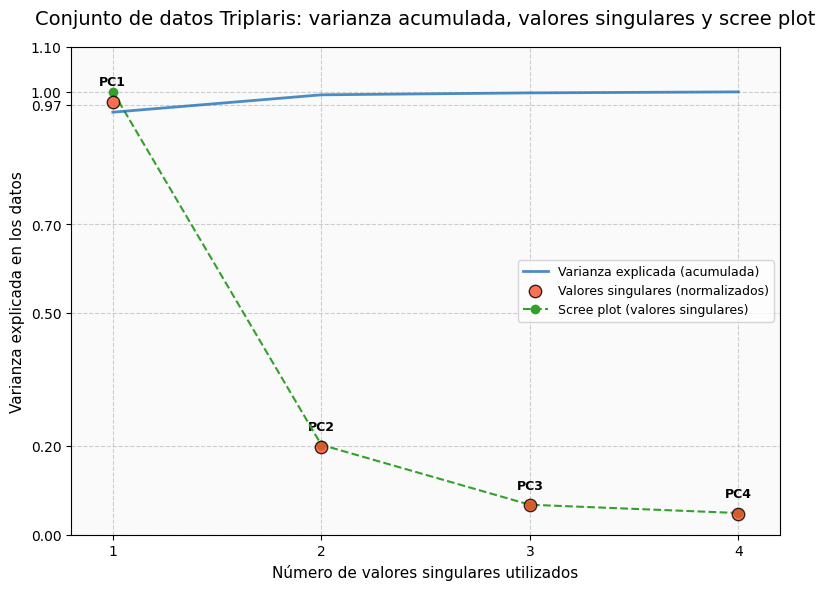

Ecuacion que representa a PC1: 

PC1 = (-0.0269)*a_mm + (-0.0386)*s_mm + (-0.1331)*t_mm + (-0.1028)*r1_mm + (-0.1035)*r2_mm + (-0.1013)*r3_mm + (-0.0631)*theta1 + (-0.4576)*theta2 + (-0.8566)*theta3 + (-0.0221)*w1_mm + (-0.0220)*w2_mm + (-0.0214)*w3_mm


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn import preprocessing

# Antes de iniciar poner el dataset en archivos

# Install odfpy to read .ods files
!pip install odfpy

# Aqui empieza el codigo

# Carga del dataAL

triplaris = pd.read_excel(
    "/content/sample_data/df_recoleccionDatosAl.ods",
    engine="odf",
    skiprows= 0,
    header =None,
)

# Seccion donde se acomoda el DataFrame
triplaris.columns = triplaris.iloc[0]
triplaris = triplaris.drop(0)
triplaris = triplaris.reset_index(drop=True)
triplaris = triplaris.replace(",", ".", regex=True) # Cambio de datos que poseen "," a "." para que no existan errores en Numpy
df_numerico = triplaris.apply(pd.to_numeric, errors="coerce") # Se encarga de convertir todo los datos a numericos
df_numerico = df_numerico.dropna()

print(f"Numero de filas: {triplaris.shape[0]} y columnas: {triplaris.shape[1]} \n ")
print(f"Se visualizan las primeros 5 filas: \n {triplaris.head(5)} \n")
print(f"Algunas estadisticas básicas del cojunto de datos: \n {triplaris.describe()} \n")


# Aplicacion de la SVD del dataset Recoleccion
X = df_numerico.to_numpy(dtype=float)
U_Triplaris, S_Triplaris, Vt_Triplaris = np.linalg.svd(X, full_matrices=False)

# Matriz U
print(f"Matriz U tiene {U_Triplaris.shape[0]} filas y {U_Triplaris.shape[1]} columnas\n")
r = U_Triplaris.shape[1]
componentes = [f"PC{i+1}" for i in range(r)]
print("Se visualizan las primgeras 5 filas de U: ")
print(f"{pd.DataFrame(U_Triplaris,columns=componentes).head(5)}\n")


# Matriz Vt
columnasTripalis =[
    "a_mm",
    "s_mm",
    "t_mm",
    "r1_mm",
    "r2_mm",
    "r3_mm",
    "theta1",
    "theta2",
    "theta3",
    "w1_mm",
    "w2_mm",
    "w3_mm"
]


print(f"La matriz Vt tiene {Vt_Triplaris.shape[0]} filas y {Vt_Triplaris.shape[1]} columnas \n")
print(f"{pd.DataFrame(Vt_Triplaris, columns = columnasTripalis)}\n")



# Determinación de la varianza
num_sv_triplaris = np.arange(1,S_Triplaris.size + 1)
cum_var_explained_triplaris = [
    np.sum(np.square(S_Triplaris[0:n]))/
    np.sum(np.square(S_Triplaris))
    for n in num_sv_triplaris
]



# Recorta los PCA que se mostrara, ya que del PC4 en adelante son irrelevantes
k = 4
num_sv_triplaris = num_sv_triplaris[:k]
cum_var_explained_triplaris = cum_var_explained_triplaris[:k]
S_Triplaris = S_Triplaris[:k]

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111)

# Línea: Varianza acumulada explicada
ax.plot(
    num_sv_triplaris,
    cum_var_explained_triplaris,
    color="#2171b5",
    label="Varianza explicada (acumulada)",
    alpha=0.8,
    linewidth=2,
    zorder=1000
)

# Puntos: valores singulares normalizados
ax.scatter(
    num_sv_triplaris,
    preprocessing.normalize(S_Triplaris.reshape((1, -1))).flatten(),
    color="#fc4e2a",
    label="Valores singulares (normalizados)",
    alpha=0.8,
    s=80,
    edgecolors="black",
    zorder=1001
)

# Línea discontinua: Scree Plot (valores singulares no normalizados)
ax.plot(
    num_sv_triplaris,
    S_Triplaris / S_Triplaris.max(),  # Escalado para compatibilidad visual
    color="#33a02c",
    linestyle="--",
    marker="o",
    linewidth=1.5,
    label="Scree plot (valores singulares)",
    zorder=999
)

# Etiquetas en puntos singulares para indicar componente
for i, (x, y) in enumerate(
    zip(
        num_sv_triplaris,
        preprocessing.normalize(S_Triplaris.reshape((1, -1))).flatten()
    )
):
    ax.text(
        x,
        y + 0.03,
        f"PC{i+1}",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold"
    )

# Etiquetas de ejes y título
ax.set_xticks(num_sv_triplaris)
ax.set_yticks([0.0, 0.2, 0.5, 0.7, 0.97, 1.0, 1.1])
ax.set_xlim(0.8, 4.2)
ax.set_ylim(0.0, 1.1)
ax.set_xlabel("Número de valores singulares utilizados", fontsize=11)
ax.set_ylabel("Varianza explicada en los datos", fontsize=11)
ax.set_title(
    "Conjunto de datos Triplaris: varianza acumulada, valores singulares y scree plot",
    fontsize=14,
    y=1.03
)

# Fondo, leyenda y grilla
ax.set_facecolor("0.98")
ax.legend(loc="center right", scatterpoints=1, fontsize=9)
ax.grid(alpha=0.6, linestyle="--", zorder=1)

plt.tight_layout()
plt.show()


# Nombres (los mismos que ya usas)
vars_ = columnasTripalis  # lista de 12 nombres

# Vector de pesos de PC1 (loadings)
pc1 = Vt_Triplaris[0, :]

# Ecuación en una sola línea (aprox)
ecuacion = " + ".join([f"({w:+.4f})*{v}" for v, w in zip(vars_, pc1)])
print("Ecuacion que representa a PC1: \n")
print("PC1 = " + ecuacion)

/tmp/ipython-input-686877548.py:16: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace(",", ".", regex=True) # Cambio de datos que poseen "," a "." para que no existan errores en Numpy


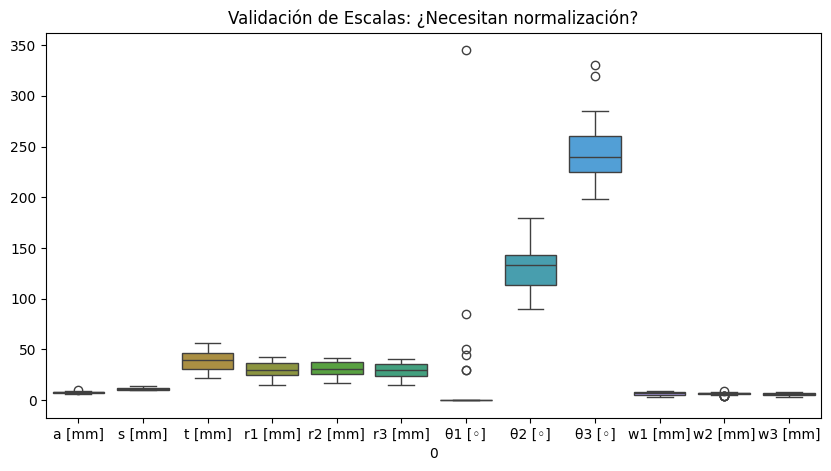

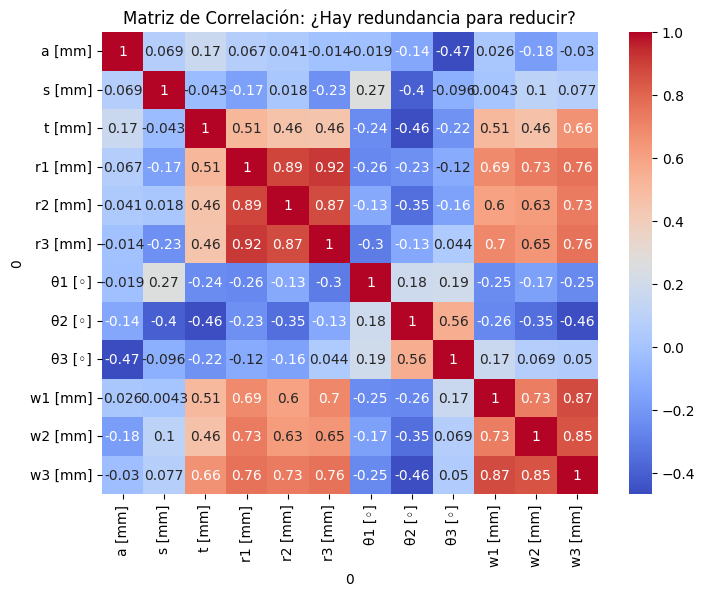

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# 1. Cargar tus datos (usa el CSV que procesé de tu .ods)
df = pd.read_excel(
    "/content/sample_data/df_recoleccionDatosAl.ods",
    engine="odf",
    skiprows= 0,
    header =None,
)
df.columns = df.iloc[0]
df = df.drop(0)
df = df.reset_index(drop=True)
df = df.replace(",", ".", regex=True) # Cambio de datos que poseen "," a "." para que no existan errores en Numpy

# 2. PROBAR SUPUESTO DE ESCALAMIENTO
plt.figure(figsize=(10,5))
sns.boxplot(data=df)
plt.title("Validación de Escalas: ¿Necesitan normalización?")
plt.show()

# 3. PROBAR SUPUESTO DE CORRELACIÓN (Linealidad)
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Matriz de Correlación: ¿Hay redundancia para reducir?")
plt.show()

# 4. APLICAR ESTANDARIZACIÓN (Requisito para SVD/PCA)
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)